## 10/03 ge calibration

T1 = 36e-06

T2_echo = 5.5e-06

T2_star = 4.8e-06

In [3]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
import sklearn
from sklearn.decomposition import PCA

In [4]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [5]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

In [43]:
header = "D:/K_Sunada/result/CDY167"
amp = "/2024-10-03/2024-10-03T142621_060e07e8-21_ge_pi_amp"
dd_amp = datadict_from_hdf5(header + amp +"/data")


Rabi_amp = dd_amp['s11']['values']
imag_amp = Rabi_amp.imag
amp = dd_amp['amplitude']['values']

I_amp = (Rabi_amp.real)
Q_amp = (Rabi_amp.imag)
PCA_amp = PCA_transform(I_amp, Q_amp)

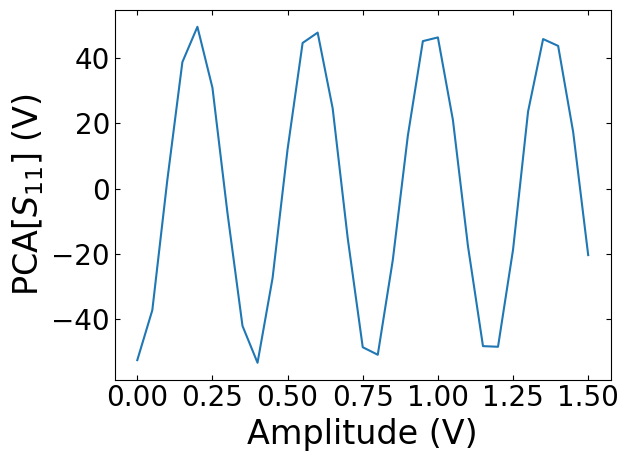

In [44]:
fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Amplitude (V)', size='large')
ax1.set_ylabel('PCA[$S_{11}$] (V)', size='large')
plt.rcParams["font.size"] = 17
plt.plot(amp, PCA_amp[0])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 1)
# ax1.set_ylim(-48, 160)
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
plt.show()

In [45]:
par_ini= {'amp': 40,'phi0':0,'detun':1/0.35,'const':1}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.inf}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}

model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result = model.fit(data = PCA_amp[0], params = params, delay = amp)
result

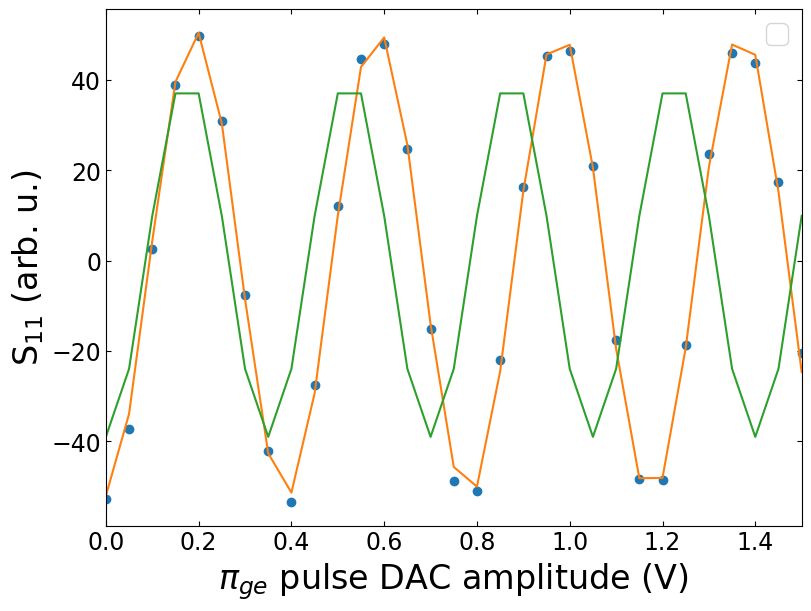

In [46]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(amp, result.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel('$\pi_{ge}$ pulse DAC amplitude (V)', size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)', size='large')
ax.set_xlim(0, 1.5)
# plt.savefig('ge_rabi.png', bbox_inches='tight')
plt.show()

In [47]:
np.pi/(2.54393851*2*np.pi)*5

0.9827281556424099

ramsey

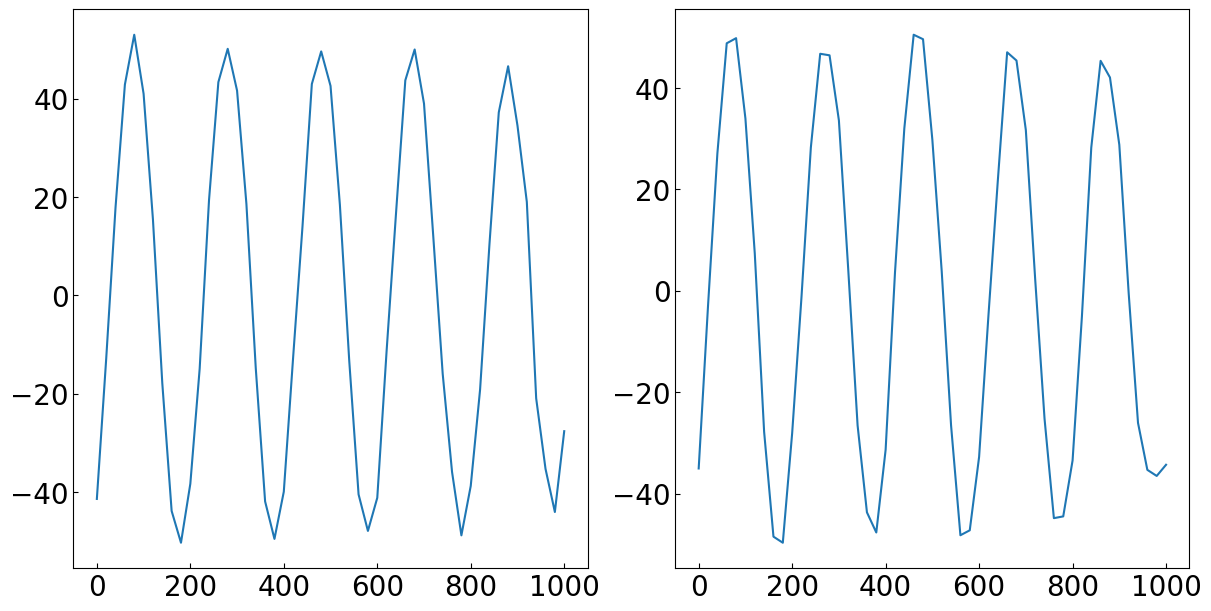

In [48]:
pl ="/2024-10-03/2024-10-03T142742_36637ef1-23_ge_T2r1d"
mi =  "/2024-10-03/2024-10-03T142839_5894c00c-23_ge_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

Rabi_pl = dd_pl['s11']['values']
delay_pl = dd_pl['delay']['values']
Rabi_mi = dd_mi['s11']['values']
delay_mi = dd_mi['delay']['values']

I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)

PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
ax[0].plot(x_pl, y_pl)
ax[1].plot(x_mi, y_mi)
plt.show()

In [52]:
par_ini_pl = {'amp': 40,'phi0':0,'detun':1/220,'const':0.1}
par_ini_mi = {'amp': 40,'phi0':0,'detun':1/180,'const':0.1}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':0}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}

model = lmfit.Model(Rabi)

params_pl = model.make_params()
for name in model.param_names:
    params_pl[name].set(value = par_ini_pl[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result_pl = model.fit(data = y_pl, params = params_pl, delay = x_pl)
result_pl

In [53]:
params_mi = model.make_params()
for name in model.param_names:
    params_mi[name].set(value = par_ini_mi[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result_mi = model.fit(data = y_mi, params = params_mi, delay = x_mi)
result_mi

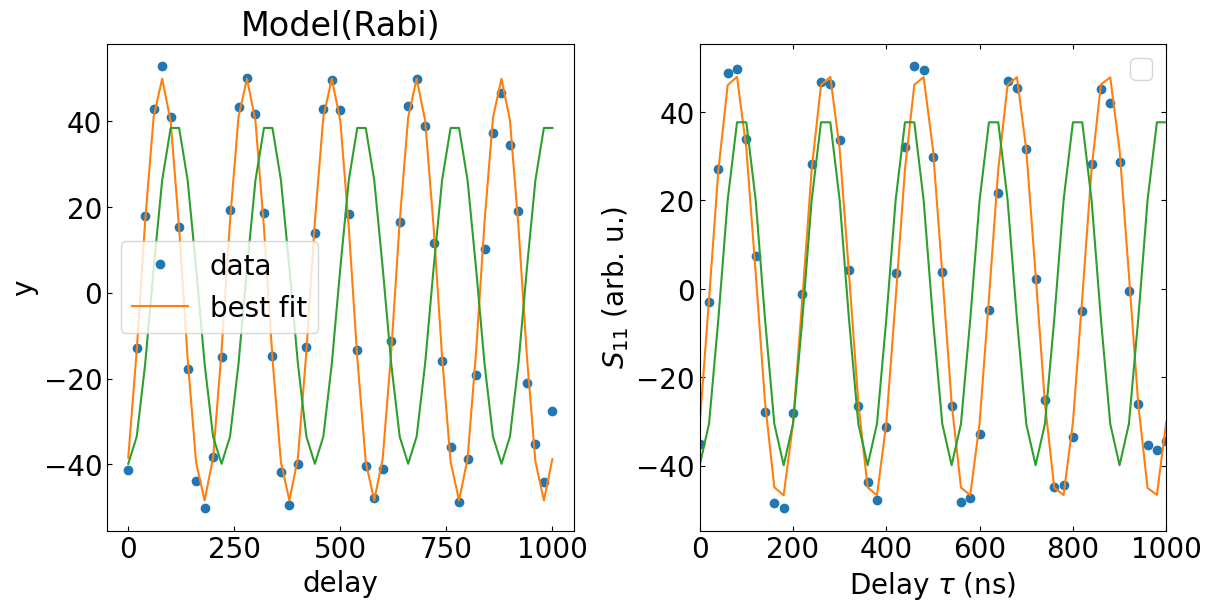

In [54]:
fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax[0])
ax[0].plot(x_pl,result_pl.init_fit)
result_mi.plot_fit(ax = ax[1])
ax[1].plot(x_mi,result_mi.init_fit)

plt.title("")
plt.legend("")
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")
plt.xlim(0, 1000)
# plt.savefig('ef_ramsey_exp.png', bbox_inches='tight')
plt.show()

In [55]:
detun = ((0.005-0.00499807)+ (0.00500167-0.005))/2 #GHz
detun

1.7999999999997185e-06

drag

In [60]:
drag = "/2024-10-03/2024-10-03T143015_919b048c-22_ge_pi_drag" # n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2024-10-03/2024-10-03T143046_a4292d2f-22_ge_pi_drag" # n=13
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2024-10-03/2024-10-03T143120_b86d7047-22_ge_pi_drag" # n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [61]:
Rabi_drag = dd_drag['s11']['values']
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [62]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

In [63]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

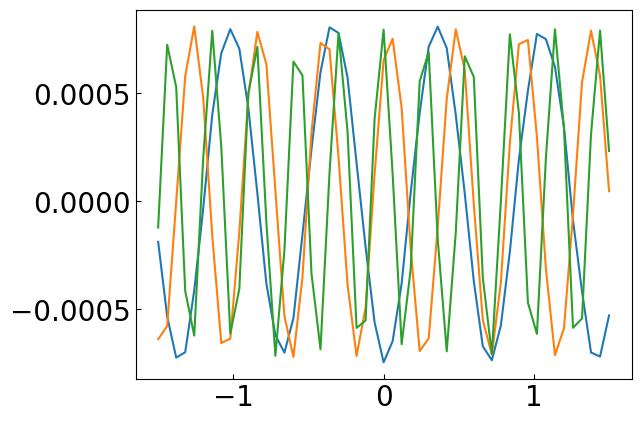

In [64]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [77]:
par_ini= {'amp': 0.0006,'phi0':np.pi,'detun':1/0.3,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.pi}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

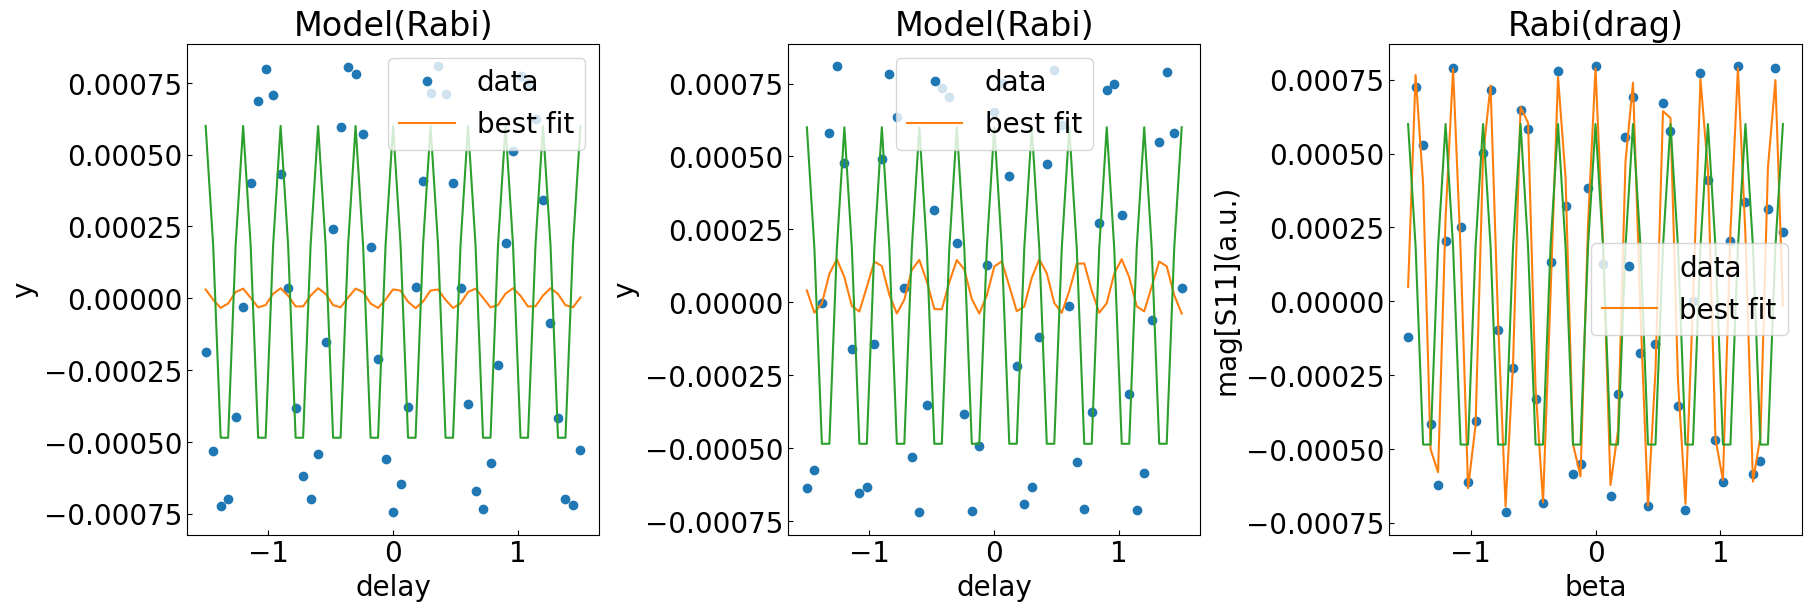

In [78]:
fig, ax = plt.subplots(1,3,figsize=(18,6),constrained_layout=True)
plt.title("Rabi(drag)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax[0])
ax[0].plot(x0,result0.init_fit)
result1.plot_fit(ax = ax[1])
ax[1].plot(x1,result1.init_fit)
result2.plot_fit(ax = ax[2])
ax[2].plot(x2,result2.init_fit)
plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")
plt.show()

In [67]:
result0

In [69]:
res0 = (0.16906672+2*np.pi)/(2*np.pi*1.44256135)
res0

0.7118642158271697

In [72]:
result1

In [76]:
res1 = (4*np.pi-2.42071584)/(2*np.pi*2.26626219)
res1

0.7125085152848755

In [79]:
result2

In [81]:
res2 = (6*np.pi-3.18346358)/(2*np.pi*3.50401465)
res2

0.7115655281549632

In [82]:
beta = (res0 + res1 + res2)/3
beta

0.7119794197556694

half drag

In [84]:
drag = "/2024-10-03/2024-10-03T143523_49628d55-22_ge_pi_drag" # n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2024-10-03/2024-10-03T143554_5bec3e7f-22_ge_pi_drag" # n=13
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2024-10-03/2024-10-03T143627_6f61aeda-22_ge_pi_drag" # n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [85]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [86]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

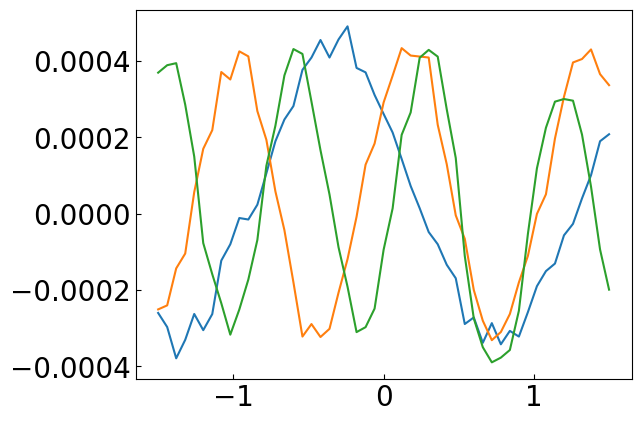

In [87]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [100]:
par_ini= {'amp': 0.0004,'phi0':np.pi/2,'detun':1/1,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.pi}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}
model = lmfit.Model(Rabi)

model = lmfit.Model(Rabi)
params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

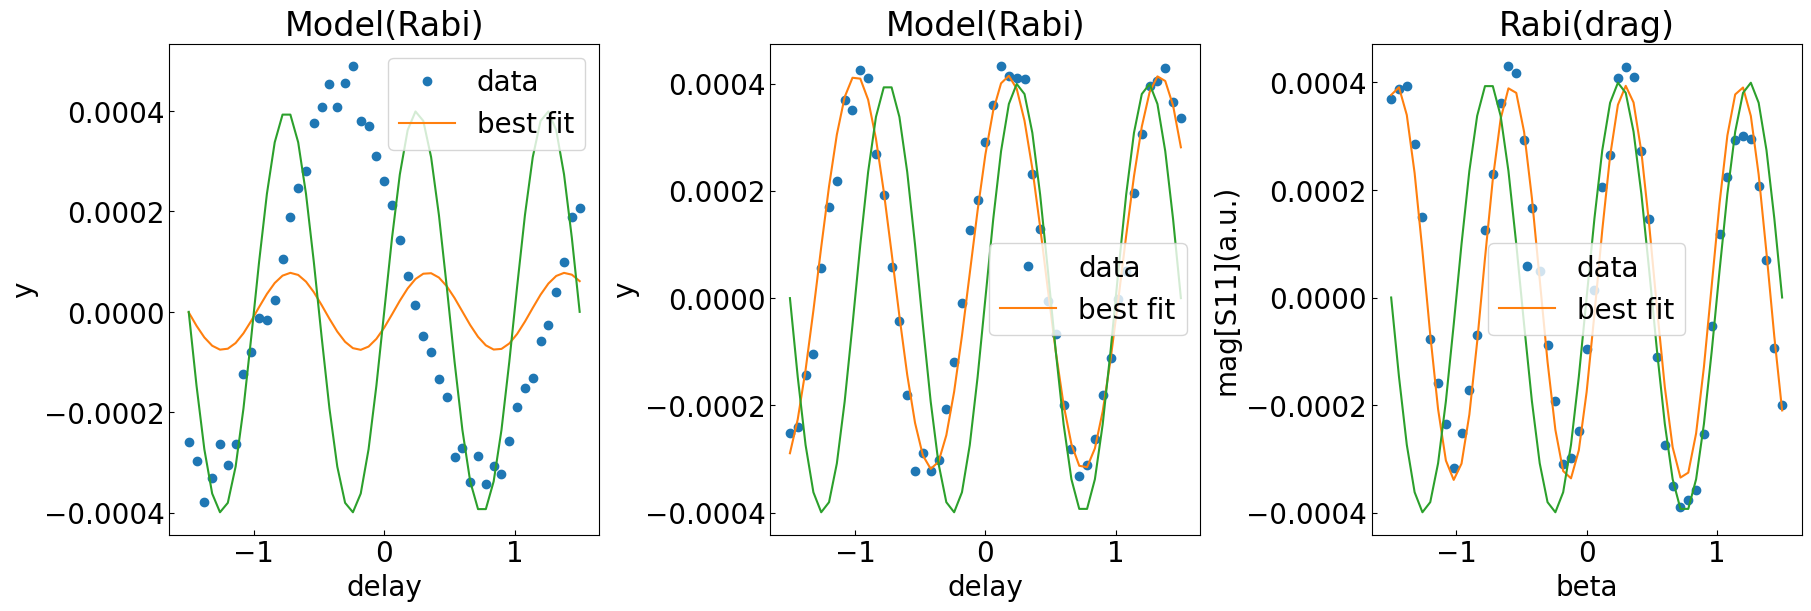

In [101]:
fig, ax = plt.subplots(1,3,figsize=(18,6),constrained_layout=True)
plt.title("Rabi(drag)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax[0])
ax[0].plot(x0,result0.init_fit)
result1.plot_fit(ax = ax[1])
ax[1].plot(x1,result1.init_fit)
result2.plot_fit(ax = ax[2])
ax[2].plot(x2,result2.init_fit)
plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")
plt.show()

In [90]:
result0

In [92]:
res0 = (2.22270610)/(2*np.pi*0.46046154)
res0

0.7682610427257587

In [97]:
result1

In [99]:
res1 = (2*np.pi-2.21400971)/(2*np.pi*0.85866408)
res1

0.7542290701155756

In [102]:
result2

In [104]:
res2 = (2*np.pi-0.98447133)/(2*np.pi*1.13689929)
res2

0.7417688874607773

In [105]:
beta = (res0 + res1 + res2)/3
beta

0.7547530001007039

T1

In [106]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2024-10-03/2024-10-03T143930_dcc04782-24_ge_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

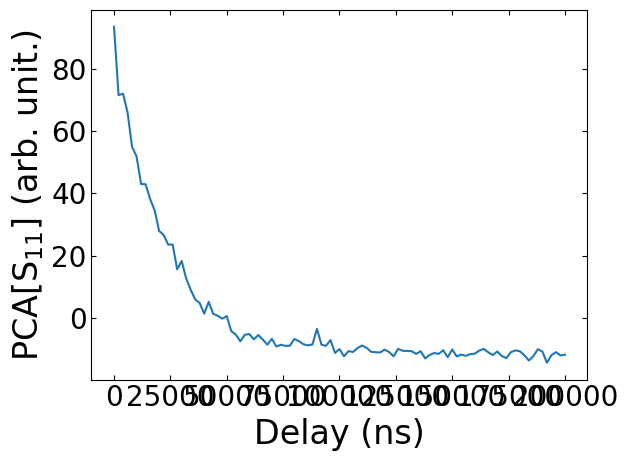

In [107]:
s11_t1 = dd_t1['s11']['values']#[0:180]
delay_t1 = dd_t1['delay']['values']#[0:180]
I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)
PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Delay (ns)', size='large')
ax1.set_ylabel('PCA[S$_{11}$] (arb. unit.)', size='large')
plt.rcParams["font.size"] = 10
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 250000)
# ax1.set_ylim(-48, 160)
plt.tick_params(top='on',bottom='on`',left='on',right='on',)

plt.plot(x_t1, y_t1)
plt.show()

In [108]:
par_ini_t1 = {'gamma': 1/40000e-3,'amp':1,'const':-2.4}
par_min_t1 = {'gamma': 0,'amp':0,'const':-np.inf}
par_max_t1 = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary_t1 = {'gamma': True,'amp':True,'const':True}

model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = y_t1, params = params, delay = x_t1*1e-3)
result_t1

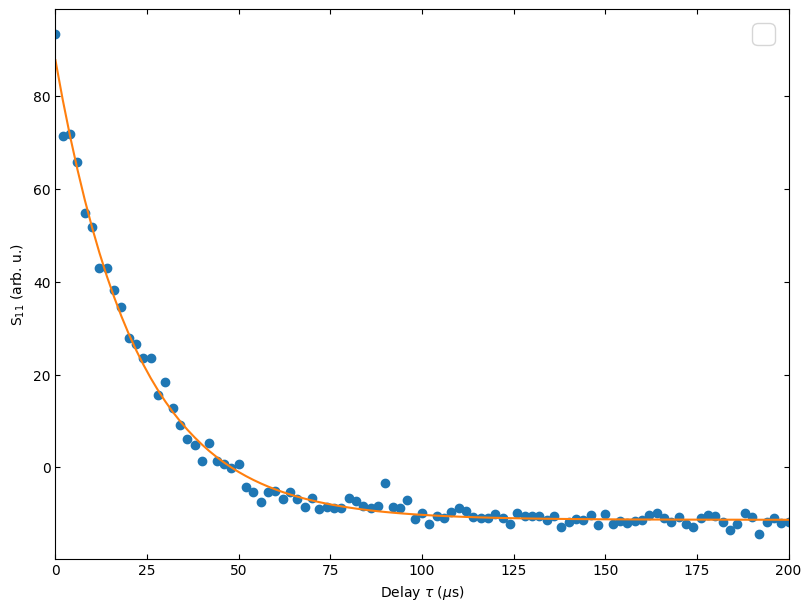

In [109]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t1.plot_fit(ax = ax)
# plt.plot(x_t1,result_t1.init_fit, label='init fit')
# ax.set_ylim(-8, 15)
plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')#, size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)')
plt.xlim(0, 200)
# plt.savefig('ge_T1.png', bbox_inches='tight')
plt.show()

In [110]:
T1 = (1/0.04526587)*1e-9	
T1

2.2091699552002425e-08

T2_echo

In [118]:
t2e = "/2024-10-03/2024-10-03T144825_1b370e2a-25_ge_T2e"
dd_t2e = datadict_from_hdf5(header + t2e +"/data")

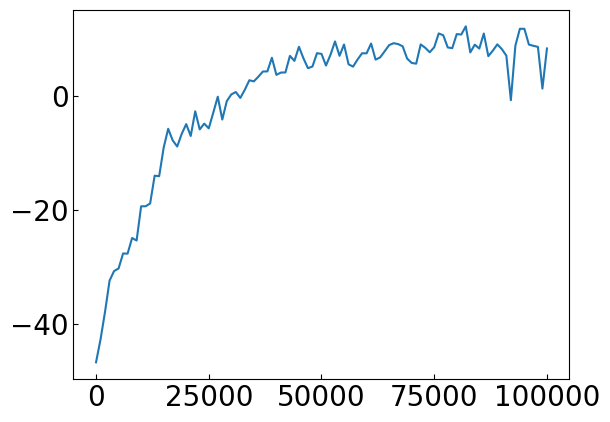

In [119]:
s11_t2e = dd_t2e['s11']['values']
delay_t2e = dd_t2e['delay']['values']
I_t2e = (s11_t2e.real)
Q_t2e = (s11_t2e.imag)
PCA_t2e = PCA_transform(I_t2e, Q_t2e)

y_t2e = PCA_t2e[0]
x_t2e = delay_t2e
plt.plot(x_t2e, y_t2e)
plt.show()

In [120]:
par_ini_t2e = {'gamma': 1/5000e-3,'amp':60,'const':-10}
par_min_t2e = {'gamma': 0,'amp':0,'const':-np.inf}
par_max_t2e = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary_t2e = {'gamma': True,'amp':True,'const':True}

model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2e[name],
    min = par_min_t2e[name],
    max = par_max_t2e[name],
    vary = par_vary_t2e[name]
    )
result_t2e = model.fit(data = -y_t2e, params = params, delay = x_t2e*1e-3)
result_t2e

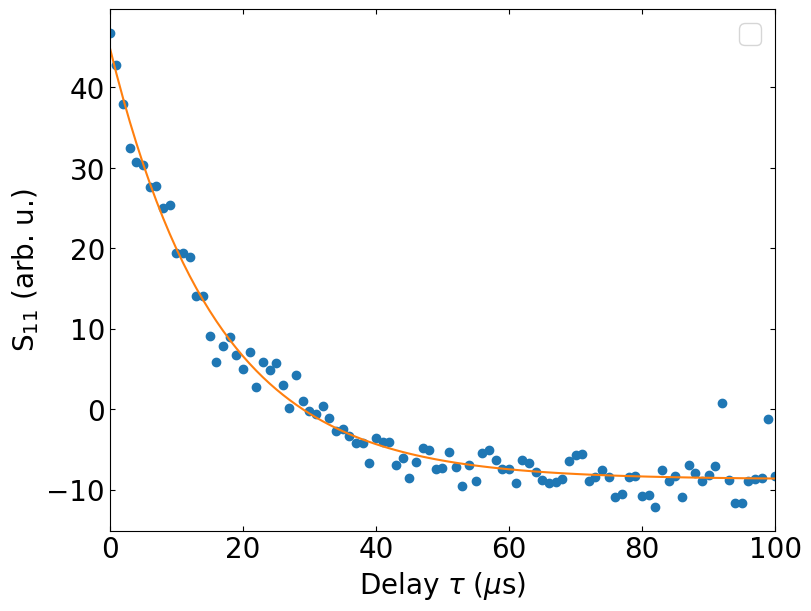

In [121]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2e.plot_fit(ax = ax)
# plt.plot(delay_t2e,result_t2e.init_fit)

# ax.set_ylim(-10, 35)

plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')
ax.set_ylabel('S$_{11}$ (arb. u.)')
plt.xlim(0, 100)
# plt.savefig('ge_T2e.png', bbox_inches='tight')
plt.show()

In [122]:
T2 = (1/0.06267605)*1e-6
T2

1.595505779320809e-05

T2 star

In [111]:
def Damping(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

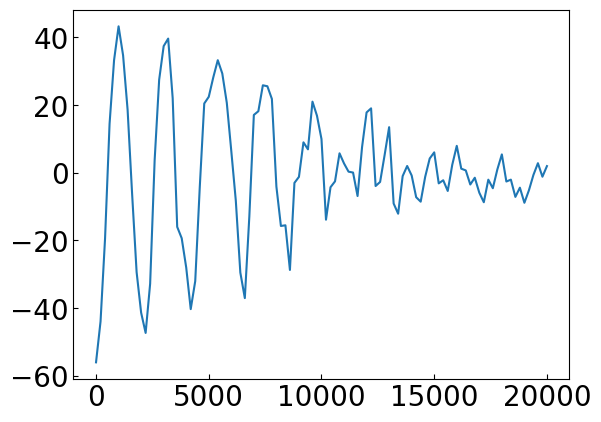

In [112]:
t2 = "/2024-10-03/2024-10-03T144534_b595a3e8-23_ge_T2r1d"
dd_t2 = datadict_from_hdf5(header + t2 +"/data")

s11_t2 = dd_t2['s11']['values']
delay_t2 = dd_t2['delay']['values']
I_t2 = (s11_t2.real)
Q_t2 = (s11_t2.imag)
PCA_t2 = PCA_transform(I_t2, Q_t2)

y_t2 = PCA_t2[0]
x_t2 = delay_t2

plt.plot(x_t2, y_t2)
plt.show()

In [113]:
par_ini_t2 = {'amp':60,'gamma': 1/3000e-3,'omega':2*np.pi/2500e-3,'phi0':0,'const':0}
par_min_t2 = {'amp':-np.inf,'gamma': 0,'omega':-2*np.pi,'phi0':-2*np.pi,'const':-np.inf}
par_max_t2 = {'amp':np.inf,'gamma': np.inf,'omega':np.inf,'phi0':2*np.pi,'const':np.inf}
par_vary_t2 = {'amp':True,'gamma': True,'omega':True,'phi0':True,'const':True}

model = lmfit.Model(Damping)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini_t2[name],min = par_min_t2[name],max = par_max_t2[name],vary = par_vary_t2[name])
result_t2 = model.fit(data = y_t2, params = params, delay = x_t2*1e-3)
result_t2

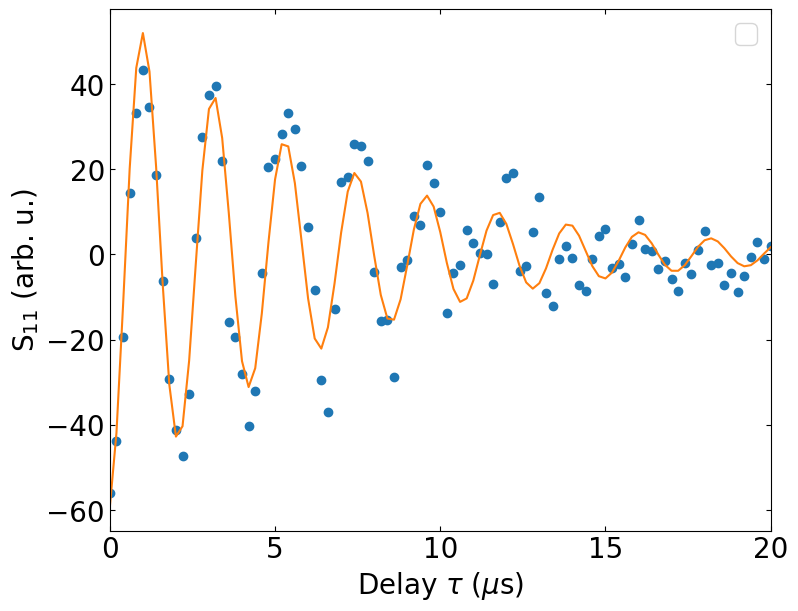

In [114]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2.plot_fit(ax = ax)
# plt.plot(delay_t2*1e-3,result_t2.init_fit)
# ax.set_ylim(-10, 35)
plt.title("")
plt.legend("")
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')
ax.set_ylabel('S$_{11}$ (arb. u.)')
ax.set_xlim(0, 20)
# plt.savefig('ge_T2star.png', bbox_inches='tight')
plt.show()

In [115]:
T2_star = (1/0.15553320)*1e-6
T2_star

6.429495438915935e-06